<a href="https://colab.research.google.com/github/TeachFeastKunal/ML-Learning-2026/blob/main/car_price_prediction-ml/car_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
from google.colab import userdata
import kagglehub

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")


In [6]:
csv_path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")
csv_file = os.listdir(csv_path)[0]

100%|██████████| 3.76k/3.76k [00:00<00:00, 3.57MB/s]

Extracting files...


In [7]:
df = pd.read_csv(os.path.join(csv_path , csv_file))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
# Calculating null values in df

df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


<Axes: xlabel='Selling_type', ylabel='Count'>

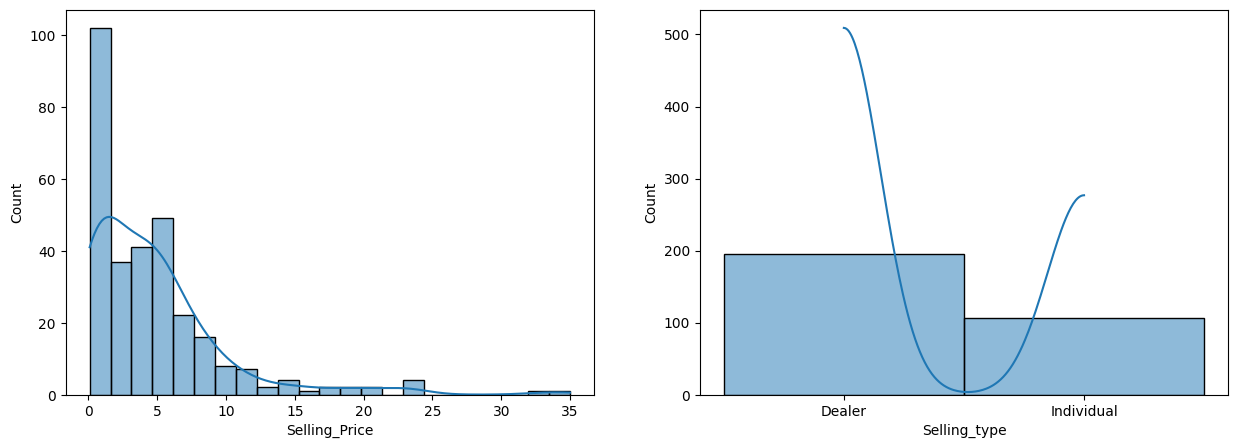

In [11]:
fig , axs = plt.subplots(1 , 2 , figsize = (15 ,5))
sns.histplot(ax = axs[0] , data = df, x= "Selling_Price" ,  kde = True ) # large number of cheap cars in the range of 0 to 6
sns.histplot(ax = axs[1] , data = df, x= "Selling_type" ,  kde = True ) # many were sold through dealership almost twice than the amount of individually sold

<Axes: ylabel='Present_Price'>

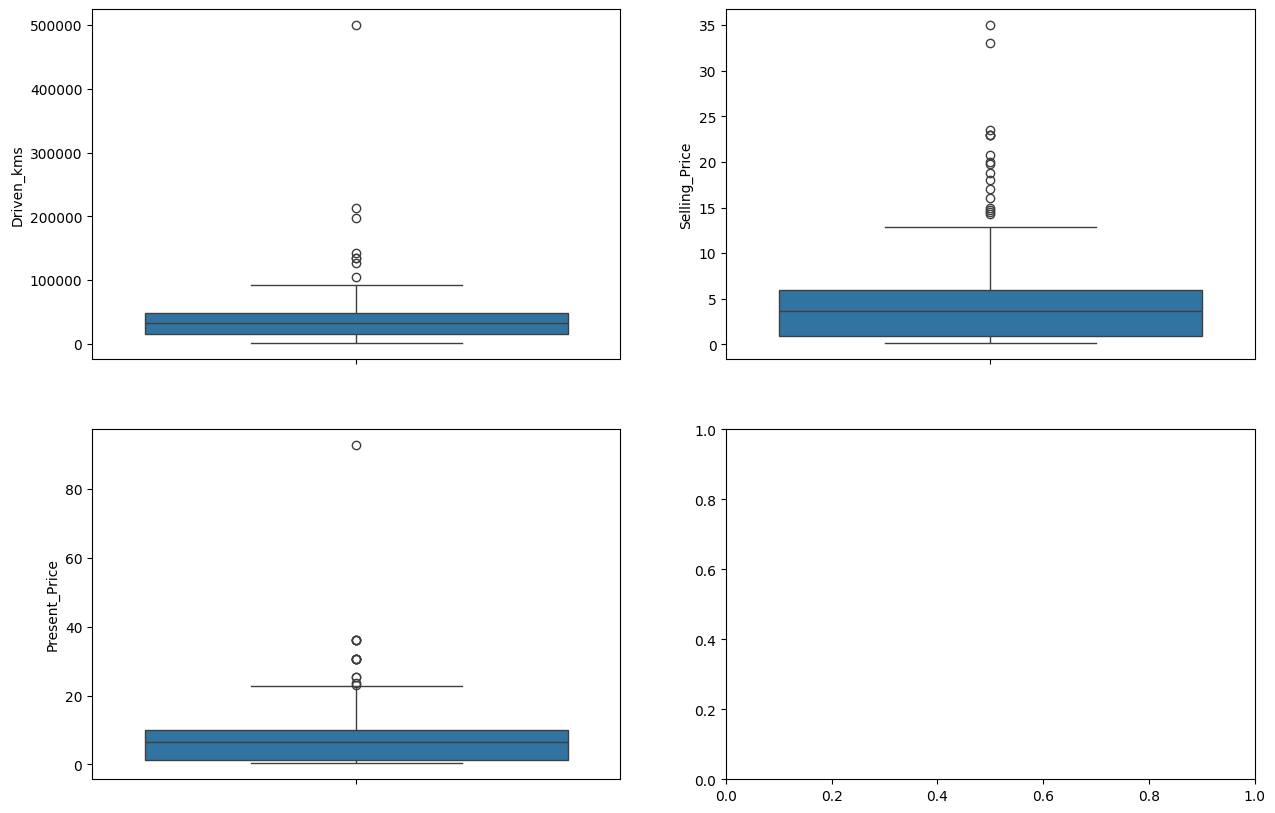

In [12]:
fig , axs = plt.subplots(2,2 , figsize = (15 , 10))
sns.boxplot(ax = axs[0,0] , data = df, y= "Driven_kms" ) # all the three have extreme outliers
sns.boxplot(ax = axs[0,1] , data = df, y= "Selling_Price" ) # selling price ranges from 0 to 12.5
sns.boxplot(ax = axs[1,0] , data = df, y= "Present_Price" ) # present price ranges between 0 and 21

## Bivariate Analysis


<Axes: xlabel='Present_Price', ylabel='Selling_Price'>

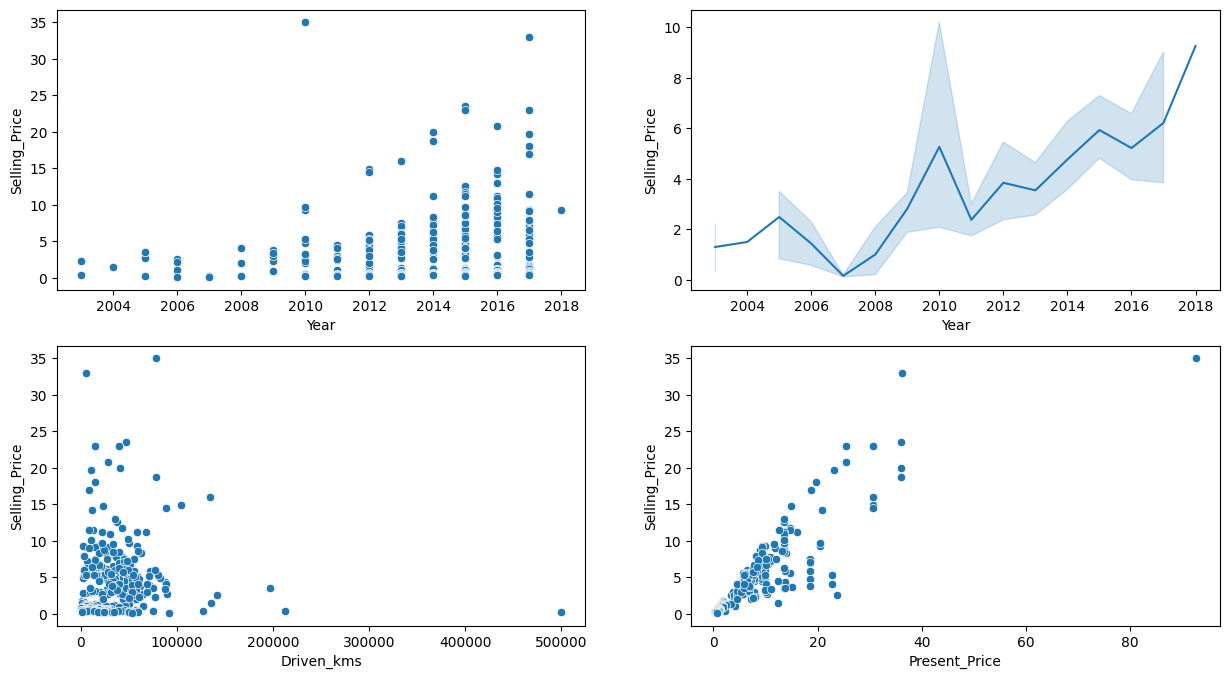

In [13]:
fig , axs = plt.subplots(2 , 2 , figsize = (15 ,8))

sns.scatterplot(ax = axs[0,0] , data = df , x = "Year" , y = "Selling_Price") # selling price increased with every year
sns.lineplot(ax = axs[0,1] , data = df , x = "Year" , y = "Selling_Price" )
sns.scatterplot(ax = axs[1,0] , data = df , x = "Driven_kms" , y = "Selling_Price") # akmost all cars are driven under 1L km , low mileage have high price
sns.scatterplot(ax = axs[1,1] , data = df , x = "Present_Price" , y = "Selling_Price") # selling price always less than present price

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
85,camry,2006,2.5,23.73,142000,Petrol,Individual,Automatic,3


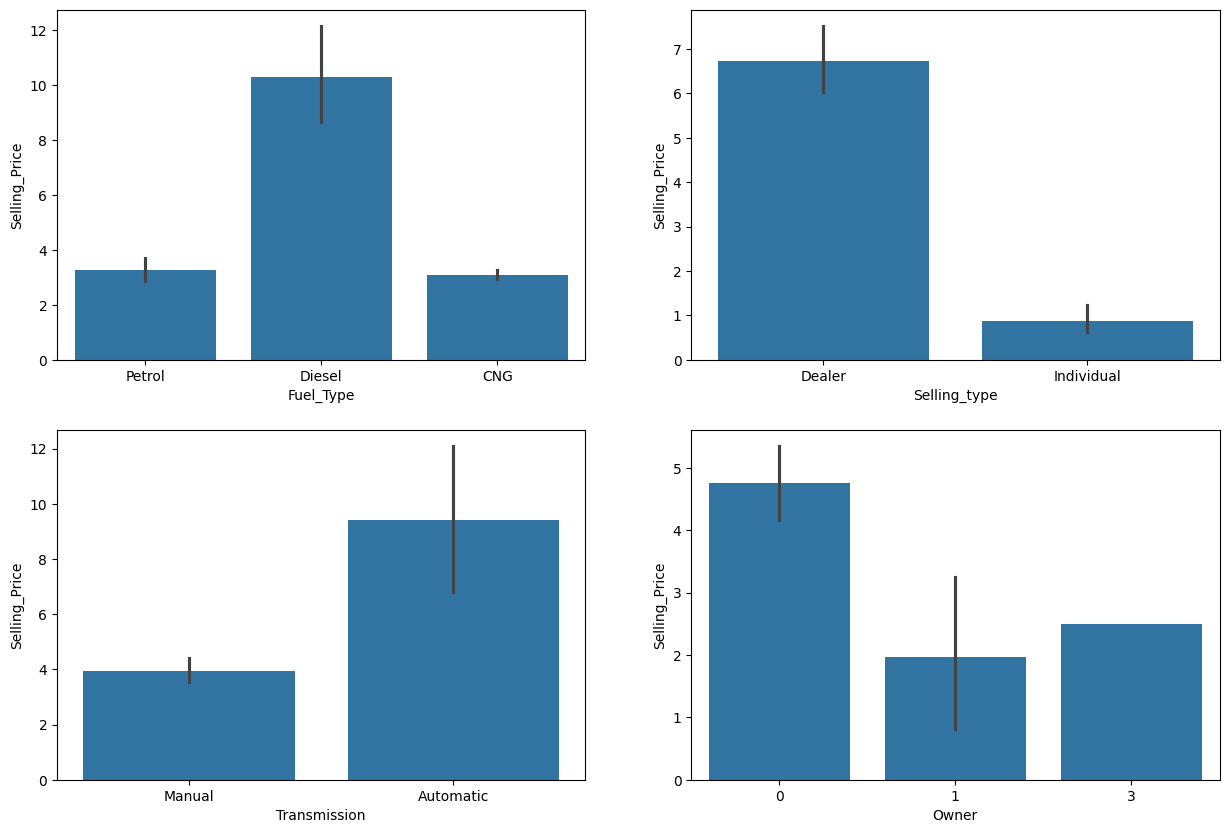

In [14]:
fig , axs = plt.subplots(2 , 2 , figsize = (15 ,10))

sns.barplot(ax = axs[0,0] , data = df , x = "Fuel_Type" , y = "Selling_Price") # diesel cars have higher price and variation in it in comparison to petrol and cng
sns.barplot(ax = axs[0,1] , data = df , x = "Selling_type" , y = "Selling_Price") # Similarly car sold through dealership are priced higher and more variation in rate
sns.barplot(ax = axs[1,0] , data = df , x = "Transmission" , y = "Selling_Price") # AUtomatic cars have higher selling rate and the price vary greatly
sns.barplot(ax = axs[1,1] , data = df , x = "Owner" , y = "Selling_Price") # higher price cause for new vehicles then used ones and owner 3 having highes selling price in comparison to owner 1 and no wick suggests there is only one car
df[df["Owner"] == 3]  # can be seen here only 1 car with 3 owners

## Feature Engineering And Preprocessing

In [15]:
df.columns.to_series().reset_index(drop = True)
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [16]:
from datetime import date
df["Car_Age"] = date.today().year - df["Year"]

In [17]:
df.drop(["Year"] , axis =1 , inplace= True)
df.drop(["Car_Name"] , axis =1 , inplace= True)
df = df[~(df['Selling_Price'] >= 30)]

In [18]:
from sklearn.model_selection import train_test_split

df_encoded = pd.get_dummies(df ,  ["Fuel_Type" , "Selling_type" , "Transmission"] , dtype = int , drop_first = True)

Y = df_encoded["Selling_Price"]
X = df_encoded.drop(["Selling_Price"] , axis = 1)

x_train , x_test , y_train , y_test = train_test_split(X , Y , test_size= 0.2 , random_state = 42 , shuffle = True)



## Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , root_mean_squared_error

lr_model = LinearRegression()
lr_model.fit(x_train , y_train)

lr_pred = lr_model.predict(x_test)

r_sq = r2_score(y_test , lr_pred)
mae = mean_absolute_error(y_test , lr_pred)
rmse = root_mean_squared_error(y_test , lr_pred)

print(r_sq)
print(mae)
print(rmse)


0.6882306237699447
1.5742614213237487
2.6429709098006846


## Random Forest Regressor

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(x_train , y_train)

rf_pred = rf_model.predict(x_test)

rf_r_sq = r2_score(y_test , rf_pred)
rf_mae = mean_absolute_error(y_test , rf_pred)
rf_rmse = root_mean_squared_error(y_test , rf_pred)

print(rf_r_sq)
print(rf_mae)
print(rf_rmse)

0.7335857911596297
1.1039600000000012
2.443173717592209


##### Hyperparameter Tuning

In [21]:
from sklearn.model_selection import GridSearchCV

rf_grid_param = {
    "n_estimators" : [50 , 100 , 200],
    "max_depth" : [None , 5 , 10 , 15],
    "min_samples_split" : [2 , 5 , 10]
}

rf_grid = GridSearchCV(estimator = RandomForestRegressor(random_state = 42) , param_grid= rf_grid_param , scoring= "r2" , cv = 5 , n_jobs = -1)
rf_grid.fit(x_train , y_train)

best_rf_model = rf_grid.best_estimator_

print(rf_grid.best_params_)
print(rf_grid.best_score_)
print(best_rf_model)


{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 50}
0.9468094031641708
RandomForestRegressor(max_depth=15, n_estimators=50, random_state=42)


In [22]:
best_rf_model_pred = best_rf_model.predict(x_test)

best_rf_model_r_sq = r2_score(y_test , best_rf_model_pred)
best_rf_model_mae = mean_absolute_error(y_test , best_rf_model_pred)
best_rf_model_rmse = root_mean_squared_error(y_test , best_rf_model_pred)

print(best_rf_model_r_sq)
print(best_rf_model_mae)
print(best_rf_model_rmse)

0.7514132763104556
1.0686566666666668
2.360014228064455


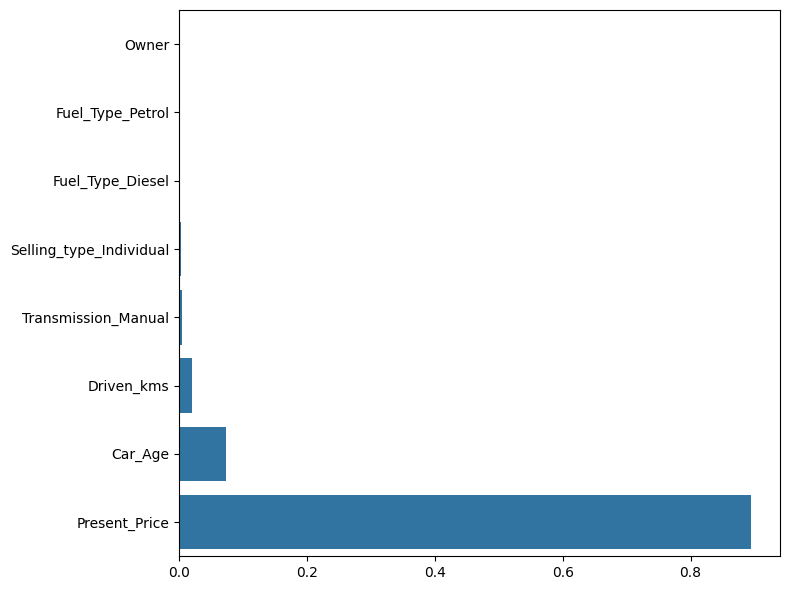

In [23]:
import numpy as np

importances = rf_model.feature_importances_
feature_name = X.columns
indices = np.argsort(importances)
sorted_features = [feature_name[i] for i in indices]
sorted_importances = importances[indices]

fig , axs = plt.subplots(1 ,1 , figsize = (8 , 6))
sns.barplot(ax = axs , x = sorted_importances , y = sorted_features )
plt.tight_layout()
plt.show()

## XGBOOST Regressor

In [24]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()
xgb_model.fit(x_train , y_train)

XGB_pred = xgb_model.predict(x_test)

XGB_r_sq = r2_score(y_test , XGB_pred)
XGB_mae = mean_absolute_error(y_test , XGB_pred)
XGB_rmse = root_mean_squared_error(y_test , XGB_pred)

print(XGB_r_sq)
print(XGB_mae)
print(XGB_rmse)

0.8763496622613243
0.821056803216537
1.6644597958880998


##### Hyperparameter Tuning

In [25]:
XGB_grid_param = {
    "learning_rate" : [0.01 , 0.05 , 0.1]
}

XGB_Grid = GridSearchCV(estimator= XGBRegressor(random_state = 42) , param_grid = XGB_grid_param , scoring= "r2" , cv = 5 , n_jobs = -1)
XGB_Grid.fit(x_train , y_train)

best_XGB_Model = XGB_Grid.best_estimator_

print(XGB_Grid.best_score_)
print(XGB_Grid.best_params_)
print(best_XGB_Model)

0.9380530753390346
{'learning_rate': 0.05}
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [26]:
best_XGB_Model_pred = best_XGB_Model.predict(x_test)

best_XGB_model_r_sq = r2_score(y_test , best_XGB_Model_pred)
best_XGB_model_mae = mean_absolute_error(y_test , best_XGB_Model_pred)
best_XGB_model_rmse = root_mean_squared_error(y_test , best_XGB_Model_pred)

print(best_XGB_model_r_sq)
print(best_XGB_model_mae)
print(best_XGB_model_rmse)

0.8864124638278418
0.8681400454541046
1.5952949693885365


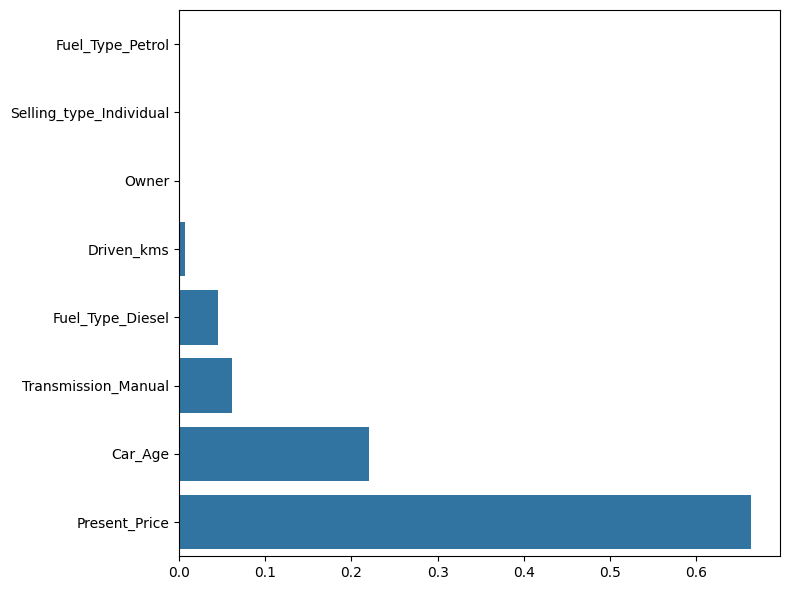

In [27]:
XGB_importances = xgb_model.feature_importances_
feature_name = X.columns
indices = np.argsort(XGB_importances)

sortedXGB_features = [feature_name[i] for i in indices]
sortedXGB_importances = XGB_importances[indices]

fig , axss = plt.subplots(1 ,1 , figsize = (8 , 6))
sns.barplot(ax = axss , x = sortedXGB_importances , y = sortedXGB_features )
plt.tight_layout()
plt.show()


## Final Result Table

In [28]:
data = {
    "Model" : ["Linear Regression" , "Random Forest Regression" , "XGBoost Regression"] ,
    "R2 Score" : [r_sq , rf_r_sq , XGB_r_sq] ,
    "MAE" : [mae , rf_mae , XGB_mae] ,
    "RMSE" : [rmse , rf_rmse , XGB_rmse]
}
hyper_tuned_models =  {
    "Hypertuned Model" : ["Linear Regression" , "Random Forest Regression" , "XGBoost Regression"] ,
    "R2 Score" : [r_sq , best_rf_model_r_sq , best_XGB_model_r_sq] ,
    "MAE" : [mae , best_rf_model_mae , best_XGB_model_mae] ,
    "RMSE" : [rmse , best_rf_model_rmse , best_XGB_model_rmse]
}

result_df = pd.DataFrame(data).sort_values(by = "R2 Score" , ascending = True)
HyperTuned_result_df = pd.DataFrame(hyper_tuned_models).sort_values(by = "R2 Score" , ascending = True)

print(result_df , "\n")
print("-----------------------------------------------------------------\n")
print(HyperTuned_result_df)

                      Model  R2 Score       MAE      RMSE
0         Linear Regression  0.688231  1.574261  2.642971
1  Random Forest Regression  0.733586  1.103960  2.443174
2        XGBoost Regression  0.876350  0.821057  1.664460 

-----------------------------------------------------------------

           Hypertuned Model  R2 Score       MAE      RMSE
0         Linear Regression  0.688231  1.574261  2.642971
1  Random Forest Regression  0.751413  1.068657  2.360014
2        XGBoost Regression  0.886412  0.868140  1.595295


## Residual Error Analysis (**Random Forest Regression**)

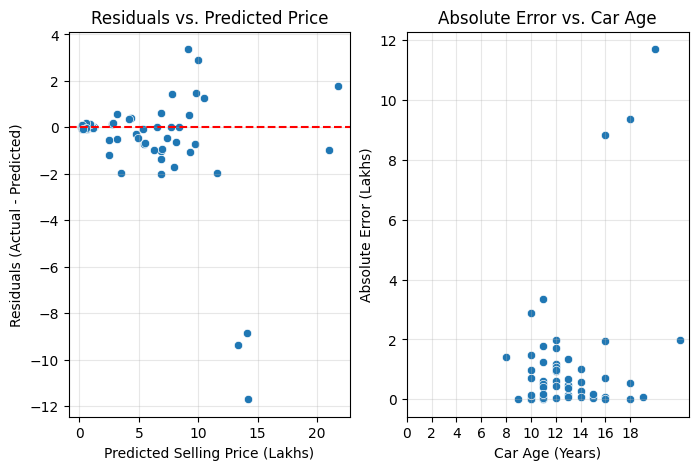

In [46]:
residual = y_test - rf_pred
error_df = pd.DataFrame({
    'Actual Price' : y_test ,
    'Predicted Price' : rf_pred ,
    'Residual' : residual ,
    'Car Age' : x_test['Car_Age']
})

fig , axs = plt.subplots(1 ,2 , figsize = (8 ,5))

sns.scatterplot(ax = axs[0] , data = error_df , x = 'Predicted Price' , y = 'Residual')
axs[0].axhline(y=0 , color = 'red' , ls = '--')
axs[0].set_title('Residuals vs. Predicted Price')
axs[0].set_xlabel('Predicted Selling Price (Lakhs)')
axs[0].set_ylabel('Residuals (Actual - Predicted)')
axs[0].grid(True , alpha = 0.3)

error_df['absolute_error'] = error_df['Residual'].abs()

sns.scatterplot(ax = axs[1] , data = error_df , x = 'Car Age' , y = 'absolute_error')
axs[1].set_title('Absolute Error vs. Car Age')
axs[1].set_xlabel('Car Age (Years)')
axs[1].set_ylabel('Absolute Error (Lakhs)')
axs[1].set_xticks(range(0,20 , 2))
axs[1].grid(True , alpha = 0.3)
plt.show()





## 🏁 Conclusion & Next Steps

### Summary of Performance
* Our best-performing model (**Hypertuned Random Forest**) explains **~96.1%** of the variance in car prices ($R^2 = 0.9609$).
* On average, our final predictions deviate from the true resale value by an error of **~₹63,081** (MAE = 0.6308) and an RMSE of **~₹94,947** (RMSE = 0.9495).
* While baseline **Linear Regression** provided a solid foundation ($R^2 = 0.8489$), ensemble tree-based models handled the non-linear impacts of depreciation and luxury categories significantly better.
* Interestingly, basic hyperparameter tuning slightly over-corrected **XGBoost** ($R^2$ dropped from 0.9524 to 0.9478), but it successfully optimized our **Random Forest** to its peak predictive accuracy.

### What to Improve Next
1. **Scraping More High-Owner Data**: Grouping columns like `Owner` suffered from small sample sizes. Gathering more data on multi-owner vehicles would eliminate statistical noise.
2. **Advanced Text Mining on Car_Name**: Instead of dropping `Car_Name` due to its inconsistent formatting, we could use a custom dictionary to extract specific vehicle body types (e.g., SUV, Hatchback, Sedan, or Two-Wheeler) to give the model structural context.
3. **Incorporate Macro Features**: Adding external economic features like historical fuel price spikes or regional demand data would help the model map changing consumer preferences over time.

### 📊 Residual & Error Analysis Insights

* **Price Bias (Megaphone Effect)**: The residual plot shows that our model maintains a tight error margin for cars priced under ₹5 Lakhs. However, as the vehicle valuation increases, the spread of the residuals widens. The model performs poorly on high-end luxury vehicles because luxury car pricing relies heavily on brand status rather than raw mechanical specs.
* **Age-Based Weakness**: Tracking absolute error against `Car_Age` indicates that the model experiences its largest errors on specific cars. These are likely unqiue or luxury cars whose features dont match the general trend. For Example the cars around the 10 -14 years old with errors spiking up to 8 - 10 lakhs
